ЛАБОРАТОРНАЯ РАБОТА ПО ОБРАБОТКЕ ИЗОБРАЖЕНИЙ #5
 
1. Реализуйте высокочастотную фильтрацию на основе ядра Гаусса
-------------------------------------------------------------
Изображение periodic_noise.JPG успешно загружено:
Обработка с sigma = 4...
Обработка с sigma = 20...
Обработка с sigma = 50...
Обработка с sigma = 100...
Обработка с sigma = 150...


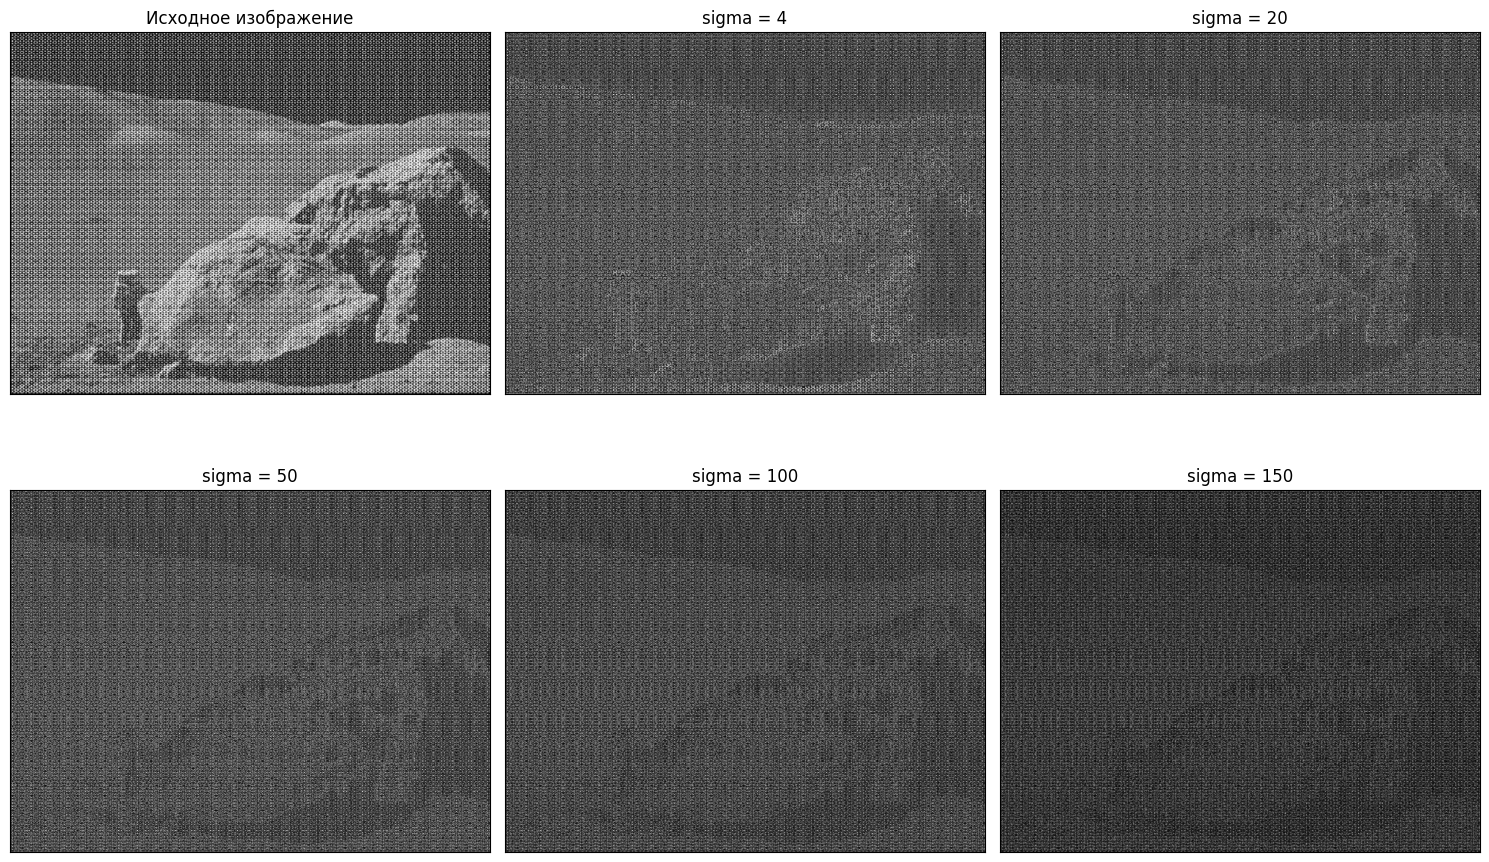

In [5]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity
import os

print("="*50)
print("ЛАБОРАТОРНАЯ РАБОТА ПО ОБРАБОТКЕ ИЗОБРАЖЕНИЙ #5")
print("="*50)
print(" ")

###1 ЗАДАНИЕ : Реализуйте высокочастотную фильтрацию на основе ядра Гаусса
print("1. Реализуйте высокочастотную фильтрацию на основе ядра Гаусса")
print("-"*61)
img = cv.imread('periodic_noise.jpg', cv.IMREAD_GRAYSCALE)   # Загружаем изображение
if img is None:
    print("Изображение не найдено")
else:
    print("Изображение periodic_noise.JPG успешно загружено:")

sigma_values = [4, 20, 50, 100, 150] # Массив значений sigma для сравнения фильтрации

dft = cv.dft(np.float32(img), flags=cv.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

rows, cols = img.shape
x, y = np.meshgrid(np.arange(0, cols, 1), np.arange(0, rows, 1))

plt.figure(figsize=(15, 10))

# Исходное изображение в первой ячейке
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Исходное изображение')
plt.xticks([])
plt.yticks([])

# Применяем фильтрацию с разными значениями sigma
for id, sigma in enumerate(sigma_values):
    # Создаем гауссово ядро
    gaussian_lowpass = np.exp(-((x - (cols // 2))**2 + (y - (rows // 2))**2) / (2 * sigma**2))
    gaussian_highpass = 1 - gaussian_lowpass  # Инвертируем в высокочастотный фильтр

    dft_shift = dft_shift * gaussian_highpass[:, :, np.newaxis]

    f_ishift = np.fft.ifftshift(dft_shift)
    img_back = cv.idft(f_ishift)
    img_back = cv.magnitude(img_back[:,:,0],img_back[:,:,1])

    plt.subplot(2, 3, id + 2)
    plt.imshow(img_back, cmap='gray')
    plt.title(f'sigma = {sigma}')
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()
